## Model Evaluation

### Setup

In [1]:
import os
import gc
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
import seaborn as sns
import albumentations as alb
import torch
from torch.utils.data import Dataset, DataLoader
from monai.networks.nets import AttentionUnet as MAttentionUnet


/home/hakeem.at/.conda/envs/BTSeg/lib/python3.12/site-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.5' (you have '2.0.4'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [2]:
seed = 42
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


### Data

In [4]:
def create_dataset_path_df(dataset_dir):
    flair_suffix = "flair.nii.gz"
    t1_suffix = "t1.nii.gz"
    t1ce_suffix = "t1ce.nii.gz"
    t2_suffix = "t2.nii.gz"
    seg_suffix = "seg.nii.gz"
    dataset_dict = {
                    'directory_path':[],
                    'flair_path':[],
                    't1_path':[],
                    't1ce_path':[],
                    't2_path':[],
                    'seg_path':[]
                    }
    missing_flair = 0
    missing_t1 = 0
    missing_t1ce = 0
    missing_t2 = 0
    missing_seg = 0
    missing_files_dirs = []
    for dir in os.listdir(dataset_dir):
        dir_path = os.path.join(dataset_dir,dir)
        if not os.path.isdir(dir_path) or not dir.startswith('BraTS2021'):
            continue
        dataset_dict['directory_path'].append(dir_path)
        
        flair_found = t1_found = t1ce_found = t2_found = seg_found = False
        for image in os.listdir(dir_path):
            image_path = os.path.join(dir_path, image)

            if image.endswith(flair_suffix):
                dataset_dict['flair_path'].append(image_path)
                flair_found = True
            elif image.endswith(t1_suffix):
                dataset_dict['t1_path'].append(image_path)
                t1_found = True
            elif image.endswith(t1ce_suffix):
                dataset_dict['t1ce_path'].append(image_path)
                t1ce_found = True
            elif image.endswith(t2_suffix):
                dataset_dict['t2_path'].append(image_path)
                t2_found = True
            elif image.endswith(seg_suffix):
                dataset_dict['seg_path'].append(image_path)
                seg_found = True

        if not flair_found:
            dataset_dict['flair_path'].append(None)
            missing_flair += 1
        if not t1_found:
            dataset_dict['t1_path'].append(None)
            missing_t1 += 1
        if not t1ce_found:
            dataset_dict['t1ce_path'].append(None)
            missing_t1ce += 1
        if not t2_found:
            dataset_dict['t2_path'].append(None)
            missing_t2 += 1
        if not seg_found:
            dataset_dict['seg_path'].append(None)
            missing_seg += 1
        if flair_found or t1_found or t1ce_found or t2_found or seg_found:
            pass
        else:
            missing_files_dirs.append(dir_path)
    print(f"Total missing files:")
    print(f"  - Flair: {missing_flair}")
    print(f"  - T1: {missing_t1}")
    print(f"  - T1ce: {missing_t1ce}")
    print(f"  - T2: {missing_t2}")
    print(f"  - Seg: {missing_seg}")
    print(f"Missing files at: {missing_files_dirs}")
    return pd.DataFrame(dataset_dict)

    return dataset_dict
dataset_dir = "Data"
dataset = create_dataset_path_df(dataset_dir)
dataset.head()

Total missing files:
  - Flair: 0
  - T1: 0
  - T1ce: 0
  - T2: 0
  - Seg: 0
Missing files at: []


,directory_path,flair_path,t1_path,t1ce_path,t2_path,seg_path
0,Data/BraTS2021_00000,Data/BraTS2021_00000/BraTS2021_00000_flair.nii.gz,Data/BraTS2021_00000/BraTS2021_00000_t1.nii.gz,Data/BraTS2021_00000/BraTS2021_00000_t1ce.nii.gz,Data/BraTS2021_00000/BraTS2021_00000_t2.nii.gz,Data/BraTS2021_00000/BraTS2021_00000_seg.nii.gz
1,Data/BraTS2021_00002,Data/BraTS2021_00002/BraTS2021_00002_flair.nii.gz,Data/BraTS2021_00002/BraTS2021_00002_t1.nii.gz,Data/BraTS2021_00002/BraTS2021_00002_t1ce.nii.gz,Data/BraTS2021_00002/BraTS2021_00002_t2.nii.gz,Data/BraTS2021_00002/BraTS2021_00002_seg.nii.gz
2,Data/BraTS2021_00003,Data/BraTS2021_00003/BraTS2021_00003_flair.nii.gz,Data/BraTS2021_00003/BraTS2021_00003_t1.nii.gz,Data/BraTS2021_00003/BraTS2021_00003_t1ce.nii.gz,Data/BraTS2021_00003/BraTS2021_00003_t2.nii.gz,Data/BraTS2021_00003/BraTS2021_00003_seg.nii.gz
3,Data/BraTS2021_00005,Data/BraTS2021_00005/BraTS2021_00005_flair.nii.gz,Data/BraTS2021_00005/BraTS2021_00005_t1.nii.gz,Data/BraTS2021_00005/BraTS2021_00005_t1ce.nii.gz,Data/BraTS2021_00005/BraTS2021_00005_t2.nii.gz,Data/BraTS2021_00005/BraTS2021_00005_seg.nii.gz
4,Data/BraTS2021_00006,Data/BraTS2021_00006/BraTS2021_00006_flair.nii.gz,Data/BraTS2021_00006/BraTS2021_00006_t1.nii.gz,Data/BraTS2021_00006/BraTS2021_00006_t1ce.nii.gz,Data/BraTS2021_00006/BraTS2021_00006_t2.nii.gz,Data/BraTS2021_00006/BraTS2021_00006_seg.nii.gz


### Custom Dataset Class

In [5]:
class BrainTumorDataset(Dataset):
    def __init__(self, datapath_df, upper_bound=100, lower_bound=60, window_size = 3, new_height=None, new_width=None,transformations=None):
        self._datapath_df = datapath_df
        self.upper_bound = upper_bound
        self.lower_bound = lower_bound
        self.window_size = window_size
        self.transformations = transformations

    def __len__(self):
        return self._datapath_df.shape[0]

    def _normalize_data(self, volume):
        mean = np.mean(volume)
        if mean==0:
            mean = 1
        std = np.std(volume)
        return (volume-mean)/std

    def _get_adjacent_slices(self, data, mask):
        slices = []
        masks = []
        
        depth = data.shape[-1]
        start = max(self.lower_bound, 0)
        end = min(self.upper_bound, depth)
        
        for i in range(start, end - self.window_size + 1):
            if self.window_size == 1:
                slice_group = data[:, :, :, i].transpose(1, 2, 0).astype(np.float32)
            else:
                slice_group = np.concatenate(
                    [data[:, :, :, j].transpose(1, 2, 0).astype(np.float32) for j in range(i, i + self.window_size)], 
                    axis=-1
                )
            slices.append(slice_group)
            masks.append(mask[:, :, i + self.window_size // 2].astype(np.uint8))
        
        return slices, masks

    def __getitem__(self, index):
        data = []
        row = self._datapath_df.iloc[index]
        data.append(self._normalize_data(nib.load(row.flair_path).get_fdata()))
        data.append(self._normalize_data(nib.load(row.t1_path).get_fdata()))
        data.append(self._normalize_data(nib.load(row.t1ce_path).get_fdata()))
        data.append(self._normalize_data(nib.load(row.t2_path).get_fdata()))
        data = np.stack(data, axis=0)
        height = data.shape[1] if not new_height else new_height
        width = data.shape[2] if not new_width else new_width
        num_modalities = data.shape[0]
        num_slices = self.window_size


        mask = nib.load(row.seg_path).get_fdata()
        mask[mask == 4] = 3
        data, mask = self._get_adjacent_slices(data, mask)
        if self.transformations:
            spatial_transforms = self.transformations.get('spatial_transforms',None)
            intensity_transforms = self.transformations.get('intensity_transforms',None)

            if spatial_transforms:
                for i in range(len(data)):
                    augmented_data = spatial_transforms(image=data[i], mask=mask[i])
                    data[i], mask[i] = augmented_data["image"], augmented_data["mask"]
            if intensity_transforms:
                for i in range(len(data)):
                    augmented_data = intensity_transforms(image=data[i])
                    data[i] = augmented_data["image"]

        for i in range(len(data)):
            data[i] = data[i].reshape((height, width, num_slices, num_modalities))
            data[i] = data[i].transpose(3, 2, 0, 1)
        return data, mask

In [6]:
new_height = 240
new_width = 240
percentage_crop = 30
transformations = {}
val_transformations = {}
val_spatial_transforms = alb.Compose([
    alb.PadIfNeeded(min_height=new_height, min_width=new_width),
    alb.Resize(new_height, new_width)
], additional_targets={"mask":"mask"})

In [7]:
upper_bound=100
lower_bound=60
window_size = 1
num_modalities = 4
test_data = BrainTumorDataset(dataset,
                             upper_bound=upper_bound, 
                             lower_bound=lower_bound, 
                             window_size = window_size, 
                             transformations=None)
pd.Series({
    'Test dataset size:': len(test_data),
}).to_frame().style.hide(axis='columns')

Test dataset size:,5


In [8]:
def collate_fn(batch):
    data = []
    mask = []
    for X, label in batch:
        data.extend(X)
        mask.extend(label)
    data = np.array(data)
    mask = np.array(mask)
    data = torch.tensor(data, dtype=torch.float32)
    mask = torch.tensor(mask, dtype=torch.float32)
    return data, mask

per_datapoint_batch_size = (upper_bound-lower_bound)-window_size+1
batch_size_multiplication_factor = 2
batch_size = int(per_datapoint_batch_size*batch_size_multiplication_factor)
num_workers = 3
persistent_workers = True
pin_memory = True if device=='cuda' else False
pin_memory_device = device
data_loader_params = {
    'batch_size': batch_size_multiplication_factor,
    'num_workers': num_workers,
    'persistent_workers': persistent_workers,
    'pin_memory': pin_memory,
    'pin_memory_device': pin_memory_device,
    'collate_fn': collate_fn,
}
print(f'Number of datapoints per batch {batch_size}')
test_dataloader = DataLoader(test_data, **data_loader_params)

Number of datapoints per batch 80


In [9]:
pd.Series({
    'Number of batches in test dataLoader:': len(test_dataloader),
}).to_frame().style.hide(axis='columns')

Number of batches in test dataLoader:,3


In [10]:
for batch_idx, (data, mask) in enumerate(test_dataloader):
    print("Unique values in masks:", torch.unique(mask))
    
    print(f"Batch {batch_idx}:")
    print(f"  Data shape: {data.shape}")
    print(f"  Mask shape: {mask.shape}")
    break

Unique values in masks: tensor([0., 1., 2., 3.])
Batch 0:
  Data shape: torch.Size([80, 4, 1, 240, 240])
  Mask shape: torch.Size([80, 240, 240])


### Model

In [11]:
class UNET_V0(torch.nn.Module):
    def __init__(self,):
        super(UNET_V0, self).__init__()
        self.unet = MAttentionUnet(
                        spatial_dims=2,
                        in_channels=int(num_modalities*window_size),     
                        out_channels=4,     
                        channels=(16, 32, 64, 128), 
                        strides=(2, 2, 1, 1),
                        kernel_size=3,       
                        up_kernel_size=3, 
                        dropout=0.3,
                    )

    def forward(self, X):
        X = self.unet(X)
        return X

In [12]:
model_path = 'Model/model.pth'
checkpoint = torch.load(model_path, map_location = device)
model = UNET_V0().to(device)
model.load_state_dict(checkpoint)
num_params = sum(p.numel() for p in model.parameters())
print('Number of parameters: {:.3f}K'.format(num_params / 1000))

Number of parameters: 494.456K


### Inference

In [15]:
def release_cuda_memory():
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

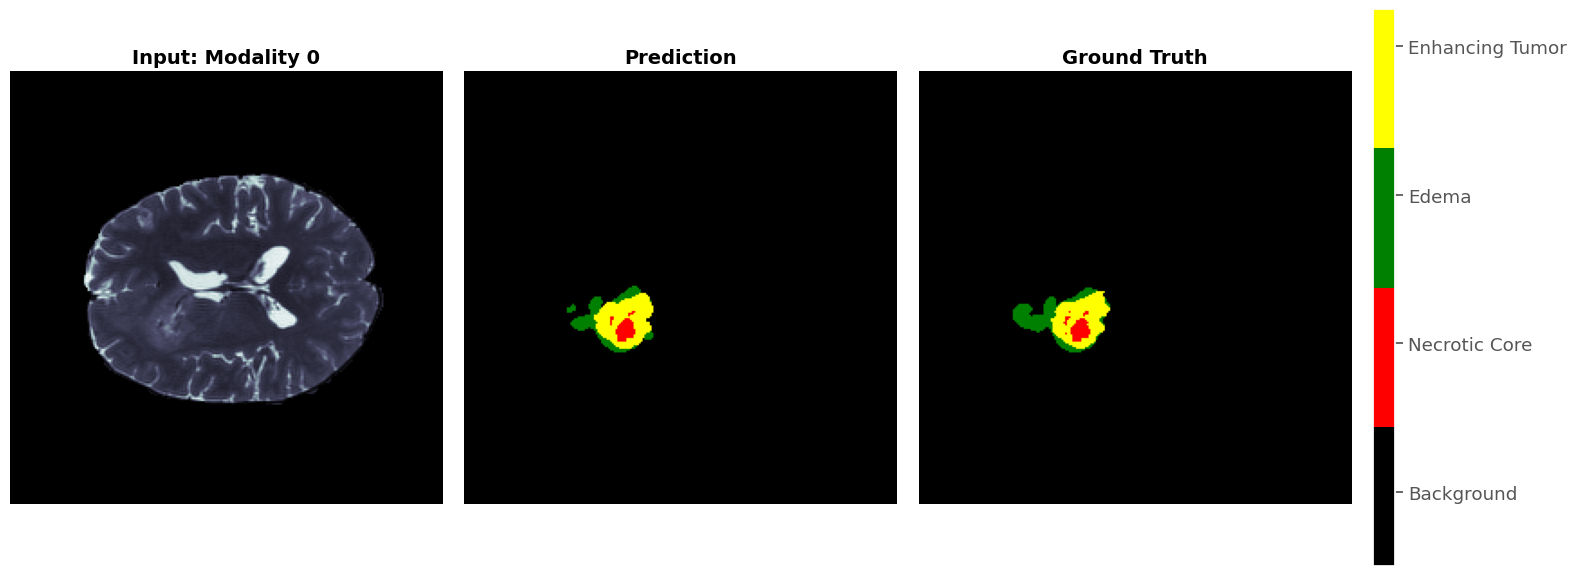

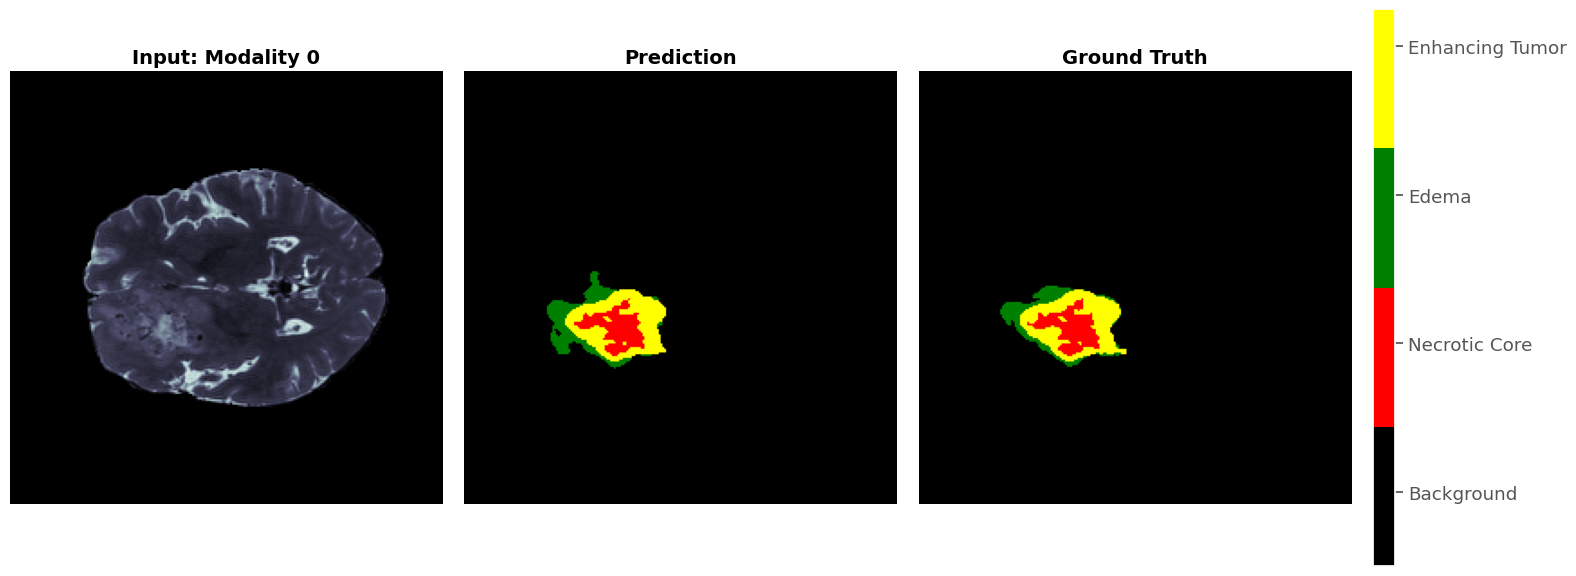

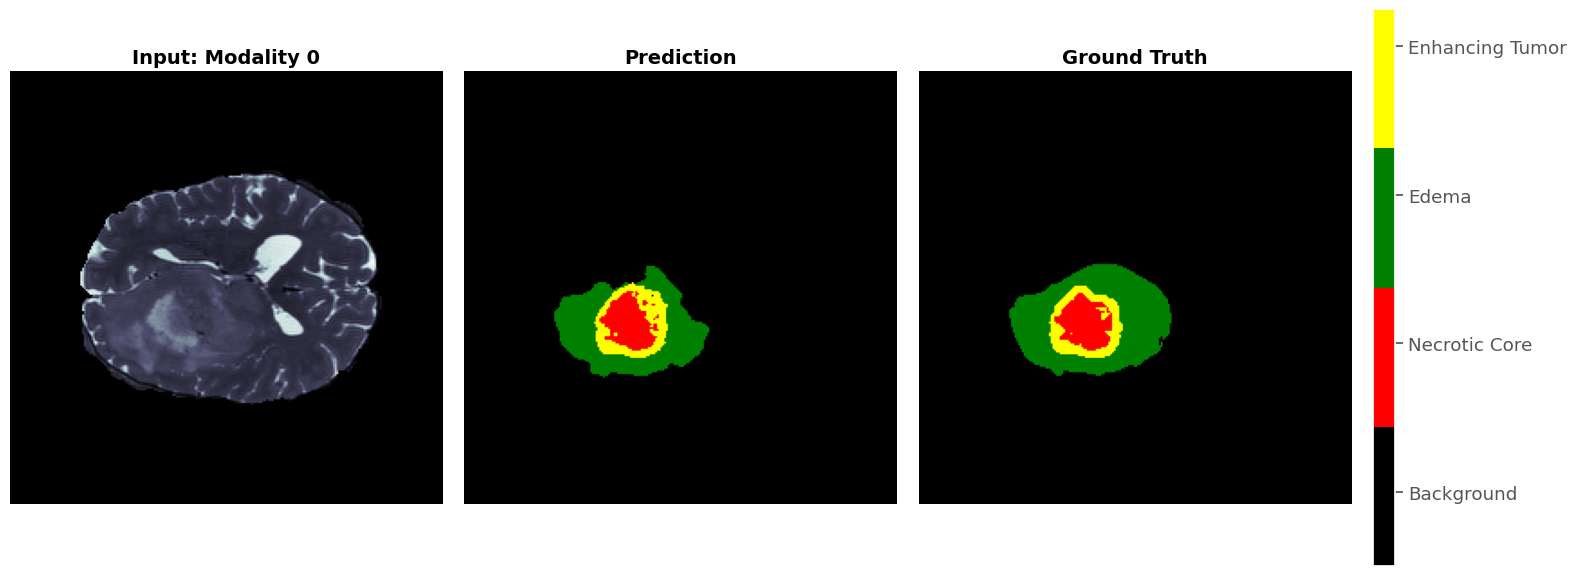

In [22]:
plt.style.use('ggplot')
sns.set_context("notebook", font_scale=1.2)

colors = ['black', 'red', 'green', 'yellow']
tumor_cmap = ListedColormap(colors)
label_names = ['Background', 'Necrotic Core', 'Edema', 'Enhancing Tumor']

def visualize_prediction(data, pred, mask, idx, modality=0, slice_num=3, save_path=None):
    fig = plt.figure(figsize=(16, 6))
    gs = gridspec.GridSpec(1, 4, width_ratios=[1, 1, 1, 0.05])
    
    ax0 = plt.subplot(gs[0])
    scan = data[idx, slice_num,...].cpu().numpy()
    im0 = ax0.imshow(scan, cmap="bone")
    ax0.set_title(f"Input: Modality {modality}", fontsize=14, fontweight='bold')
    ax0.axis('off')
    
    ax1 = plt.subplot(gs[1])
    im1 = ax1.imshow(pred, cmap=tumor_cmap, vmin=0, vmax=3)
    ax1.set_title("Prediction", fontsize=14, fontweight='bold')
    ax1.axis('off')
    
    ax2 = plt.subplot(gs[2])
    im2 = ax2.imshow(mask, cmap=tumor_cmap, vmin=0, vmax=3)
    ax2.set_title("Ground Truth", fontsize=14, fontweight='bold')
    ax2.axis('off')
    
    ax3 = plt.subplot(gs[3])
    cbar = plt.colorbar(im2, cax=ax3)
    cbar.set_ticks([0.4, 1.2, 2.0, 2.8])
    cbar.set_ticklabels(label_names)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    return fig

os.makedirs('Outputs', exist_ok=True)
num_outputs = 3

for i in range(num_outputs):
    data, masks = next(iter(test_dataloader))
    data = data.reshape(data.shape[0], -1, data.shape[-2], data.shape[-1])
    model.eval()
    with torch.no_grad():
        logits = model(data.to(device))
    
    probs = torch.softmax(logits, dim=1)
    preds = torch.argmax(logits, dim=1)
    idx = np.random.randint(preds.shape[0])
    
    modality = 0 
    slice_num = 3
    scan = data[idx, slice_num,...].cpu().numpy()
    pred = preds[idx].cpu().numpy()
    mask = masks[idx].cpu().numpy()
    
    visualize_prediction(
        data=data, 
        pred=pred, 
        mask=mask, 
        idx=idx,
        modality=modality, 
        slice_num=slice_num,
        save_path=f'Outputs/Inference_{i}.png'
    )
